# RAG and Multi-Tool AI Agents with LangChain & LangGraph

This notebook demonstrates the end-to-end implementation of:
1. **Direct LLM Invocations** via Groq API.
2. **Document Loading & Vector Search (RAG)** using HuggingFace Embeddings and InMemoryVectorStore.
3. **RetrievalQA Chains** combining prompt templates, document retrievers, and LLMs (LCEL).
4. **Multi-Tool ReAct Agents** routing user queries to specialized PDF knowledge bases.
5. **Stateful Graph Workflows (LangGraph)** with persistent conversation memory across threads.

## 1. Environment Setup & Dependencies

Install required packages for document loading, vector storage, embeddings, LangChain, and LangGraph.

In [ ]:
%pip install -qU pypdf
%pip install -U langchain
%pip install -U langchain-community
%pip install -U langchain-groq
%pip install -U langchain-huggingface
%pip install -U langgraph
%pip install -U python-dotenv

  Using cached langchain_groq-1.1.3-py3-none-any.whl.metadata (2.9 kB)
  Using cached groq-0.37.1-py3-none-any.whl.metadata (16 kB)
Using cached langchain_groq-1.1.3-py3-none-any.whl (20 kB)
Using cached groq-0.37.1-py3-none-any.whl (137 kB)


In [ ]:
import os
from dotenv import load_dotenv

# Load environment variables from .env file if available
load_dotenv()

# Support both Google Colab secrets and local environment variables
try:
    from google.colab import userdata
    for secret_key in ['GROQ_API_KEY', 'HF_TOKEN', 'GROQ_MODEL', 'HUGGINGFACE_MODEL']:
        val = userdata.get(secret_key)
        if val and not os.getenv(secret_key):
            os.environ[secret_key] = val
except ImportError:
    pass

if not os.getenv('GROQ_API_KEY'):
    print("Warning: GROQ_API_KEY not found in environment or Colab secrets.")

if os.getenv('HF_TOKEN'):
    print("HF_TOKEN loaded successfully.")

## 2. LLM Configuration & Basic Invocation

Configure ChatGroq with the target model and verify direct prompt execution.

In [ ]:
# LLM model selection with fallback to 'openai/gpt-oss-20b'
model = os.getenv('GROQ_MODEL', 'openai/gpt-oss-20b')
print(f"Using Groq model: {model}")

In [ ]:
from langchain_groq import ChatGroq

llm = ChatGroq(model=model)

prompt = """
According to NASA, what are the primary benefits of human exploration of Mars?
Respond concisely in up to 200 characters.
"""

response = llm.invoke(prompt)

In [ ]:
if response is not None:
    print(response.content)

Exploração científica, avanço em tecnologia, teste de vida longa, inspiração global, potencial de recursos, preparação para futuras missões interplanetárias.


## 3. Document Ingestion & Local Loading

Load documents from the local data/ directory to ensure reproducible, offline-friendly execution.

In [ ]:
import os

# Path to the NASA Moon to Mars Strategy document in local storage
pdf_path = os.path.join('data', 'm2m_strategy_and_objectives_development.pdf')

In [ ]:
from langchain_community.document_loaders import PyPDFLoader

pdf_loader = PyPDFLoader(pdf_path)
pages = [page for page in pdf_loader.lazy_load()]

/tmp/ipykernel_3489/1435907060.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


In [ ]:
print(f"{pages[0].metadata}\n")

{'producer': 'Adobe PDF Library 17.0', 'creator': 'Adobe InDesign 18.2 (Windows)', 'creationdate': '2023-04-06T17:28:28-04:00', 'moddate': '2023-04-06T17:29:25-04:00', 'trapped': '/False', 'source': 'https://raw.githubusercontent.com/alura-cursos/curso-flash-rag/8454fb0cfa6be5d83c6205b6ffad0af57e208efd/m2m_strategy_and_objectives_development.pdf', 'total_pages': 78, 'page': 0, 'page_label': '1'}



In [ ]:
print(pages[0].page_content)

NASA’S 
MOON TO MARS 
STRATEGY AND 
OBJECTIVES 
DEVELOPMENT
A blueprint for sustained 
human presence and 
exploration throughout 
the Solar System
National Aeronautics and
Space Administration


## 4. Vector Embeddings & Similarity Search

Generate dense semantic representations using open HuggingFace embeddings (mixedbread-ai/mxbai-embed-large-v1) and store them in an in-memory vector store.

In [ ]:
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_huggingface import HuggingFaceEmbeddings

# Embeddings model selection with fallback to 'mixedbread-ai/mxbai-embed-large-v1'
hf_model_name = os.getenv('HUGGINGFACE_MODEL', 'mixedbread-ai/mxbai-embed-large-v1')
print(f"Using Hugging Face embeddings model: {hf_model_name}")

embed_model = HuggingFaceEmbeddings(model_name=hf_model_name)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/114k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/677 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/1.24k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

In [ ]:
vector_store = InMemoryVectorStore.from_documents(pages, embed_model)

In [ ]:
docs = vector_store.similarity_search('Objectives Development Process', k=2)

In [ ]:
for doc in docs:
  print(f'Page: {doc.metadata["page"]}: {doc.page_content[:300]}\n')

Page: 42: APPENDIX B: OBJECTIVES DEVELOPMENT PROCESS
In accordance with the methodology principle of Architect from the Right, in November 2021, the NASA Executive Council 
tasked the mission directorates to draft a set of top-level goals and objectives necessary to achieve the Moon to Mars 
endeavor. The tas

Page: 13: objective-baSed approach architect From the riGht / execute From the leFt
Architect from the right 
– work backwards from 
the defined goal and 
establish a complete set 
of elements that will be 
required for success.
NASA’s Moon to Mars strategy is guided by both a robust systems engineering proce



## 5. RAG Chain Implementation with LCEL

Construct a Retrieval-Augmented Generation pipeline using LangChain Expression Language (LCEL) combining the retriever, prompt template, and LLM.

In [ ]:
retriever = vector_store.as_retriever()

In [ ]:
from langchain_core.prompts import ChatPromptTemplate

template = """You are a helpful assistant that answers strictly based on the given context. If the answer is not in the context, respond with 'I don't know'.

Context: {context}

Question: {question}

Answer:
"""

prompt = ChatPromptTemplate.from_template(template)

In [ ]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

chain = (
    {"context": retriever, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

In [ ]:
from IPython.display import display, Markdown

response = chain.invoke("What are the Objectives Development Process?")
display(Markdown(response))

The Objectives Development Process is the method NASA used to create the Moon‑to‑Mars goals and objectives. It began in November 2021 when the NASA Executive Council asked the mission directorates to draft the top‑level goals and objectives needed for the Moon‑to‑Mars effort. The process used the Federated Board to reach consensus and was organized around four distinct tracks:

1. **Science** – led by the Science Mission Directorate.  
2. **Infrastructure** – led by the Space Technology Mission Directorate.  
3. **Transportation and Habitation** – led by the Exploration Systems Development Mission Directorate.  
4. **Operations** – led by the Space Operations Mission Directorate.

The Aeronautics Mission Directorate supported the Science track and participated throughout. The Federated Board reviewed, refined, and finally agreed on an initial set of 45 objectives by March 2022. This structured, consensus‑driven approach is described in Appendix B of the document.

## 6. Multi-Domain Knowledge Bases & Custom Tools

Instantiate separate vector stores for multiple knowledge domains (NASA Moon to Mars exploration, Agriculture, Dengue fever) and define them as modular agent tools.

In [ ]:
from langchain_core.vectorstores import VectorStore

def _get_context_from_vector_store(query: str, store: VectorStore) -> str:
  """Helper function to get context search based on a specific VectorStore."""
  retriever = store.as_retriever()
  docs = retriever.invoke(query)
  # Return the content of the documents as a single string
  return "\n\n".join([doc.page_content for doc in docs])

In [ ]:
def load_pdf(file_path: str) -> InMemoryVectorStore:
    """Loads a PDF document and creates an InMemoryVectorStore index."""
    loader = PyPDFLoader(file_path)
    pages = loader.load()
    return InMemoryVectorStore.from_documents(pages, embed_model)

In [ ]:
vector_store_agriculture = load_pdf(os.path.join('data', 'agriculture.pdf'))
vector_store_dengue = load_pdf(os.path.join('data', 'dengue.pdf'))

In [ ]:
from langchain_core.tools import tool

@tool
def nasa_pdf_search(query: str) -> str:
  """Searches the NASA Moon to Mars PDF for relevant context. Use this for questions about the NASA Moon to Mars strategy and objectives development."""
  return _get_context_from_vector_store(query, vector_store)

@tool
def agriculture_search(query: str) -> str:
  """Searches the agriculture PDF for relevant context. Use this for questions about agriculture."""
  return _get_context_from_vector_store(query, vector_store_agriculture)

@tool
def dengue_search(query: str) -> str:
  """Searches the dengue PDF for relevant context. Use this for questions about dengue fever."""
  return _get_context_from_vector_store(query, vector_store_dengue)

tools = [nasa_pdf_search, agriculture_search, dengue_search]

## 7. Multi-Tool AI Agent

Initialize an agent capable of reasoning over domain queries and autonomously selecting the appropriate retrieval tool.

In [ ]:
from langchain.agents import create_agent

system_prompt = """ You're a helpful assistant that only gives answers based on the given context. If the answer is not in the context, say "I don't know".
    - nasa_pdf_search: Searches the NASA Moon to Mars PDF for relevant context. Use this for questions about the NASA Moon to Mars strategy and objectives development.
    - agriculture_search: Searches the agriculture PDF for relevant context. Use this for questions about agriculture.
    - dengue_search: Searches the dengue PDF for relevant context. Use this for questions about dengue fever.
"""

agent_pdf = create_agent(model=llm, tools=tools, system_prompt=system_prompt)

In [ ]:
first_question = agent_pdf.invoke({"messages": [("user", "What are the Objectives Development Process?")]})

{'messages': [HumanMessage(content='What are the Objectives Development Process?', additional_kwargs={}, response_metadata={}, id='c12c0d70-baa8-43dc-b674-b1352fe13a5a'), AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to answer based on context. The user asks "What are the Objectives Development Process?" Likely referring to NASA Moon to Mars PDF? The context is not given; we must search. Use nasa_pdf_search.', 'tool_calls': [{'id': 'fc_c415574f-510c-4e09-8fde-08f16ce45c5d', 'function': {'arguments': '{"query":"Objectives Development Process"}', 'name': 'nasa_pdf_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 72, 'prompt_tokens': 313, 'total_tokens': 385, 'completion_time': 0.083041081, 'completion_tokens_details': {'reasoning_tokens': 45}, 'prompt_time': 0.057365596, 'prompt_tokens_details': {'cached_tokens': 256}, 'queue_time': 0.206166533, 'total_time': 0.140406677}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerp

In [ ]:
display(Markdown(first_question['messages'][3].content))


**Objectives Development Process (NASA Moon‑to‑Mars Strategy)**  

| Step | Description |
|------|-------------|
| **Initiation (Nov 2021)** | NASA Executive Council tasked the mission directorates to draft top‑level goals and objectives that would guide the Moon‑to‑Mars endeavor. |
| **Federated Board Coordination** | The Federated Board—composed of leaders from the four mission directorates—oversaw the development and reached consensus on the initial set of objectives. |
| **Four Tracks** | Objectives were grouped into four distinct tracks, each led by a specific directorate:  
  1. **Science** – led by the Science Mission Directorate (supported by Aeronautics).  
  2. **Infrastructure** – led by the Space Technology Mission Directorate.  
  3. **Transportation & Habitation** – led by the Exploration Systems Development Mission Directorate.  
  4. **Operations** – led by the Space Operations Mission Directorate. |
| **Drafting & Gap Analysis** | An initial draft of 45 objectives was produced by March 2022. Gap analysis and cross‑assessment were conducted to identify missing elements. |
| **Public & Stakeholder Feedback (May–June 2022)** | Draft goals and objectives were released to the public and NASA workforce. Over 5,000 comments were received, leading to modifications and additions. |
| **Consultation Workshops** | Workshops with industry, academia, and international partners refined the objectives further and identified remaining gaps. |
| **Finalization** | The process produced 10 goals and 63 final objectives, reflecting a matured strategy for sustained human presence. |
| **Recurring Tenets** | A set of recurring tenets was included to address common themes across all objectives. |
| **Ongoing Review** | The strategy is dynamic; annual iterative reviews ensure that the vision, goals, and objectives evolve with new knowledge, technology, and stakeholder input while maintaining consistency and rigor. |

*The process is documented in Appendix B of the NASA Moon‑to‑Mars PDF and is guided by five methodology principles that emphasize an objective‑based, architect‑from‑the‑right approach.*

None


In [ ]:
second_question = agent_pdf.invoke({"messages": [("user", "What are the symptoms of dengue fever?")]})

{'messages': [HumanMessage(content='What are the symptoms of dengue fever?', additional_kwargs={}, response_metadata={}, id='c7bbadfa-59fb-44eb-b108-4ff69eb6c602'), AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to answer based on given context. The user asks: "What are the symptoms of dengue fever?" The relevant context is the dengue PDF. We should use dengue_search to get context. Then answer based on that. If not found, say "I don\'t know". So we need to search.', 'tool_calls': [{'id': 'fc_f0bd23a7-acde-45af-b780-8afdb0a9a32e', 'function': {'arguments': '{"query":"symptoms of dengue fever"}', 'name': 'dengue_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 91, 'prompt_tokens': 314, 'total_tokens': 405, 'completion_time': 0.109427581, 'completion_tokens_details': {'reasoning_tokens': 62}, 'prompt_time': 0.017192938, 'prompt_tokens_details': None, 'queue_time': 0.087754036, 'total_time': 0.126620519}, 'model_name': 'opena

In [ ]:
display(Markdown(second_question['messages'][2].content))


Suggested citation: European Centre for Disease Prevention and Control. Dengue. In: ECDC. Annual epidemiological report for 
2020. Stockholm: ECDC; 2022. 
 
Stockholm, April 2022 
 
© European Centre for Disease Prevention and Control, 2022. Reproduction is authorised, provided the source is acknowledged. 
 
 
 
 
 
 
 
 
 
 
 
 SURVEILLANCE REPORT 
Dengue 
 
Annual Epidemiological Report for 2020 
 
 
 
 
 
Key facts 
• For 2020, 26 EU/EEA countries reported 1 957 cases of dengue, of which 1 820 (93%) were confirmed. 
• From 2016 to 2020, no obvious trend in the number of cases could be identified.  
• The EU/EEA notification rate in 2020 was 0.5 cases per 100 000 population. 
• The highest rates in both men and women were among those aged 25–44 years. 
• The number of cases peaked in January and in August. 
• 79% of the cases with known probable country of infection were imported from the Americas, mostly 
from Martinique and Guadeloupe.  
• Twenty-four autochthonous dengue cases were reported from the EU/EEA1: 13 by France and 11 by 
Italy. 
Introduction 
Dengue is a mosquito-borne disease caused by viruses of the Flaviviridae family. The disease is widespread in 
tropical and subtropical regions. While most clinical cases present a febrile illness, severe forms have been 
reported, in some instances leading to the death of the patient. 
Methods 
This report is based on data for 2020 retrieved from The European Surveillance System (TESSy) on 25 October 
2021. TESSy is a system for the collection, analysis and dissemination of data on communicable diseases.  
For a detailed description of the methods used to produce this report, refer to the Methods chapter [1]. 
An overview of the national surveillance systems is available online [2].  
A subset of the data used for this report is available through ECDC’s online Surveillance atlas of infectious diseases  [3]. 
  
 
 
 
 
1 For the purposes of this document, the EU/EEA excludes the Outermost Regions and the Overseas Countries and Territories

SURVEILLANCE REPORT Annual epidemiological report for 2020 
 
 
7 
 
 
In 2018, the European Medicines Agency granted a marketing authorisation to the Dengvaxia vaccine, which is a 
tetravalent vaccine (live, attenuated) for the prevention of dengue [14]. The vaccine can be given to people who 
are from 9 to 45 years old, who live in endemic areas and who have had a prior dengue virus infection 
(seropositive individuals). This vaccine is therefore not recommended for populations of mainland EU/EEA, but 
could be used in EU Overseas Countries and Territories and EU Outermost Regions where dengue is endemic.  
Personal protective measures focus principally on protection against mosquito bites. Aedes mosquitoes have diurnal 
biting activities in both indoor and outdoor environments. Personal protective measures should therefore be applied 
all day long and especially during the hours of highest mosquito activity (mid-morning and late afternoon to twilight). 
Personal protective measures to reduce the risk of mosquito bites include: using mosquito bed nets (preferably 
insecticide-treated nets), sleeping or resting in screened or air-conditioned rooms, wearing clothes that cover most of 
the body, and using mosquito repellent in accordance with the instructions indicated on the product label.  
Travellers that visit dengue-endemic areas and reside in receptive areas of mainland EU/EEA should continue to 
apply personal protective measures after their return for a period of about two weeks. This is to avoid infecting 
local mosquitoes, which could result in autochthonous transmission within mainland EU/EEA. It should be noted 
that asymptomatic individuals infected with dengue virus can be infectious and therefore further transmit the virus. 
In addition, local authorities may consider conducting preventive vector control measures around imported dengue 
cases in receptive areas.

Annual epidemiological report for 2020 SURVEILLANCE REPORT 
 
 
8 
 
 
References 
1. European Centre for Disease Prevention and Control (ECDC). Introduction to the Annual Epidemiological 
Report. Stockholm: ECDC; 2020. Available at: https://ecdc.europa.eu/en/annual-epidemiological-
reports/methods 
2. European Centre for Disease Prevention and Control (ECDC). Surveillance systems overview for 2020. 
Stockholm: ECDC; 2022. Available at: https://www.ecdc.europa.eu/en/publications-data/surveillance-
systems-overview-2020 
3. European Centre for Disease Prevention and Control (ECDC). Surveillance atlas of infectious diseases - 
Dengue data. Stockholm: ECDC. [Accessed: 3 Mar 2022]. Available at: 
http://atlas.ecdc.europa.eu/public/index.aspx?Dataset=27&HealthTopic=16 
4. European Centre for Disease Prevention and Control (ECDC). Communicable disease threats report, week 51, 13-19 
December 2020. Stockholm: ECDC; 2020. Available at: 
https://www.ecdc.europa.eu/sites/default/files/documents/Communicable-disease-threats-report-19-dec-2020.pdf 
5. European Centre for Disease Prevention and Control (ECDC). Autochthonous transmission of dengue virus in 
EU/EEA, 2010-present. Stockholm: ECDC; 2022. Available at: https://www.ecdc.europa.eu/en/all-topics-
z/dengue/surveillance-and-disease-data/autochthonous-transmission-dengue-virus-eueea 
6. European Centre for Disease Prevention and Control (ECDC), European Food Safety Authority (EFSA). Aedes 
albopictus - current known distribution, October 2021. Stockholm: ECDC; 2021. Available at: 
https://www.ecdc.europa.eu/en/publications-data/aedes-albopictus-current-known-distribution-october-2021 
7. Tambyah PA, Koay ES, Poon ML, Lin RV, Ong BK, Transfusion-Transmitted Dengue Infection Study Group. 
Dengue hemorrhagic fever transmitted by blood transfusion. N Engl J Med. 2008 Oct 2;359(14):1526-7. 
Available at: https://www.ncbi.nlm.nih.gov/pubmed/18832256 
8. Oh HB, Muthu V, Daruwalla ZJ, Lee SY, Koay ES, Tambyah PA. Bitten by a bug or a bag? Transfusion-
transmitted dengue: a rare complication in the bleeding surgical patient. Transfusion (Paris). 2015 
Jul;55(7):1655-61. Available at: https://www.ncbi.nlm.nih.gov/pubmed/25728040 
9. Matos D, Tomashek KM, Perez-Padilla J, Munoz-Jordan J, Hunsperger E, Horiuchi K, et al. Probable and 
possible transfusion-transmitted dengue associated with NS1 antigen-negative but RNA confirmed-positive 
red blood cells. Transfusion (Paris). 2016 Jan;56(1):215-22. Available at: 
https://www.ncbi.nlm.nih.gov/pubmed/26469514 
10. Levi JE, Nishiya A, Felix AC, Salles NA, Sampaio LR, Hangai F, et al. Real-time symptomatic case of 
transfusion-transmitted dengue. Transfusion (Paris). 2015 May;55(5):961-4. Available at: 
https://www.ncbi.nlm.nih.gov/pubmed/25605570 
11. Rosso F, Sanz AM, Parra-Lara LG, Moncada PA, Velez JD, Caicedo LA. Dengue Virus Infection in Solid Organ 
Transplant Recipients: A Case Series and Literature Review. Am J Trop Med Hyg. 2019 Dec;101(6):1226-31. 
Available at: https://www.ncbi.nlm.nih.gov/pubmed/31628736 
12. Punzel M, Korukluoglu G, Caglayik DY, Menemenlioglu D, Bozdag SC, Tekgunduz E, et al. Dengue virus 
transmission by blood stem cell donor after travel to Sri Lanka; Germany, 2013. Emerg Infect Dis. 2014 
Aug;20(8):1366-9. Available at: https://www.ncbi.nlm.nih.gov/pubmed/25062084 
13. European Directorate for the Quality of Medicines and Healthcare of the Council of Europe. Guide to the 
preparation, use and quality assurance of blood components, 20th edition. Strasbourg: EDQM; 2020. 
Available at: https://www.edqm.eu/en/blood-guide 
14. European Medicines Agency. First vaccine for prevention of dengue. Amsterdam: EMA; 2018. Available at: 
https://www.ema.europa.eu/en/news/first-vaccine-prevention-dengue

Annual epidemiological report for 2020 SURVEILLANCE REPORT 
 
 
4 
 
 
Figure 1. Distribution of dengue cases by country, EU/EEA, 2020 
 
Source: Country reports from Austria, Belgium, Croatia, Czechia, Estonia, Finland, France, Germany, Greece, Hungary, Iceland, 
Ireland, Italy, Latvia, Lithuania, Luxembourg, Malta, the Netherlands, Norway, Poland, Portugal, Romania, Slovakia, Slovenia, 
Spain and Sweden 
Information about the month of onset, diagnosis and/or reporting was available for 1 871 cases. A large proportion 
of these cases were observed in winter and late summer, with peaks in the number of cases in January (n = 271) 
and August (n = 354) (Figures 2 and 3). When compared with previous years, the monthly numbers of cases 
reported from April to July were below the expected range. 
 
Figure 2. Distribution of dengue cases by month, EU/EEA, 2016–2020 
  
Source: Country reports from Austria, Czechia, Estonia, Finland, France, Germany, Greece, Hungary, Iceland, Ireland, Italy, 
Latvia, Malta, the Netherlands, Norway, Poland, Portugal, Romania, Slovakia, Slovenia, Spain and Sweden

None


## 8. Stateful Graph Workflows with LangGraph & Persistent Memory

Implement a cyclic workflow graph with LangGraph, complete with tool execution nodes, conditional branching, and checkpointed memory for thread-based multi-turn conversation.

In [ ]:
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import MessagesState, START, StateGraph, END
from langgraph.prebuilt import tools_condition, ToolNode

from IPython.display import Image, display
from langchain_core.messages import HumanMessage, SystemMessage

default_graph = StateGraph(MessagesState)

In [ ]:
default_graph.add_node('assistant', agent_pdf)
default_graph.add_node('tools', ToolNode(tools))

In [ ]:
default_graph.add_edge(START, 'assistant')
default_graph.add_conditional_edges('assistant', tools_condition)

In [ ]:
default_graph.add_edge('tools', 'assistant')
default_graph.add_edge('assistant', END)

In [ ]:
default_memory = MemorySaver()
app = default_graph.compile(checkpointer=default_memory)

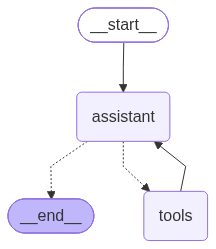

In [ ]:
Image(app.get_graph().draw_mermaid_png())

In [ ]:
def chat_with_memory(user_message: str, thread_id="1", verbose=False):
  config = {"configurable": { "thread_id": thread_id }}
  messages = app.invoke({ 'messages': [HumanMessage(content=user_message)]}, config)

  if verbose:
    for message in messages['messages']:
      message.pretty_print()
  else:
    messages['messages'][-1].pretty_print()

In [ ]:
chat_with_memory(user_message="Why is agriculture crucial for India's economy, and what's its current need?", thread_id="2", verbose = True)

================================ Human Message =================================

Why is agriculture crucial for India's economy, and what's its current need?
================================== Ai Message ==================================
Tool Calls:
  agriculture_search (fc_5e56aef7-d762-46fd-9635-62c5e4a0a4b6)
 Call ID: fc_5e56aef7-d762-46fd-9635-62c5e4a0a4b6
  Args:
    query: agriculture crucial for India's economy current need
================================= Tool Message =================================
Name: agriculture_search

International Journal of Engineering and Advanced Technology (IJEAT) 
ISSN: 2249-8958 (Online), Volume-9 Issue-1S4, December 2019 
107 
Published By: 
Blue Eyes Intelligence Engineering  
and Sciences Publication (BEIESP)  
© Copyright: All rights reserved. 
 
Retrieval Number: A11001291S419/2019©BEIESP 
DOI:10.35940/ijeat.A1100.1291S419 
Journal Website: www.ijeat.org 
 
Analysis of Crop Production Dataset using R Tool 
A. Srividhya, K.Sumathi 
Abstra

In [ ]:
chat_with_memory(user_message="What is the planet NASA is going?", thread_id="2", verbose = False)

================================== Ai Message ==================================

NASA’s current “Moon‑to‑Mars” strategy is a two‑step journey:

1. **Return to the Moon** – The Artemis program is focused on sustained human presence on the lunar surface, using the Moon as a testbed for technology, science, and long‑term operations.

2. **Proceed to Mars** – After establishing the Moon as a stepping‑stone, NASA plans to send humans to Mars and beyond, building on the capabilities and experience gained on the lunar surface.


In [ ]:
chat_with_memory(user_message="What planet again?", thread_id="2", verbose = False)

================================== Ai Message ==================================

NASA’s current plan is to **go to the Moon first**—returning humans to the lunar surface with the Artemis program—and then, once the Moon is mastered, **advance to Mars** and beyond.
